# I'll be Predicting the remaining matches in this notebook

In [ ]:
import pandas as pd
import joblib

model = joblib.load("../models/worldcup_predictor.joblib")

In [3]:
training_data = pd.read_csv("../data/processed/training_data.csv")

results = pd.read_csv("../data/raw/results.csv")

In [4]:
future_matches = results[
    results["home_score"].isna()
].copy()

future_matches

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49495,2026-07-05,Brazil,Norway,NaN,NaN,FIFA World Cup,East Rutherford,United States,True
49496,2026-07-05,Mexico,England,NaN,NaN,FIFA World Cup,Mexico City,Mexico,False
49497,2026-07-06,Portugal,Spain,NaN,NaN,FIFA World Cup,Dallas,United States,True
49498,2026-07-06,United States,Belgium,NaN,NaN,FIFA World Cup,Seattle,United States,False
49499,2026-07-06,Argentina,Egypt,NaN,NaN,FIFA World Cup,Atlanta,United States,True
49500,2026-07-06,Switzerland,Colombia,NaN,NaN,FIFA World Cup,Vancouver,Canada,True
49501,2026-07-09,France,Morocco,NaN,NaN,FIFA World Cup,Foxborough,United States,True


In [5]:
latest_brazil = training_data[
    training_data["home_team"] == "Brazil"
].iloc[-1]

In [ ]:
def get_latest_team_features(team_name):
    ...

In [6]:
import pandas as pd
import numpy as np

played_matches = pd.read_csv("../data/processed/played_matches.csv")
played_matches["date"] = pd.to_datetime(played_matches["date"])

played_matches = played_matches.sort_values("date")

In [7]:
def get_team_history(team, date):
    
    history = played_matches[
        (
            (played_matches["home_team"] == team) |
            (played_matches["away_team"] == team)
        )
        &
        (played_matches["date"] < date)
    ]

    return history

In [8]:
brazil = get_team_history(
    "Brazil",
    pd.Timestamp("2026-07-05")
)

brazil.tail()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,target
49358,2026-06-06,Brazil,Egypt,2.0,1.0,Friendly,Cleveland,United States,1,2
49410,2026-06-13,Brazil,Morocco,1.0,1.0,FIFA World Cup,East Rutherford,United States,1,1
49434,2026-06-19,Brazil,Haiti,3.0,0.0,FIFA World Cup,Philadelphia,United States,1,2
49453,2026-06-24,Scotland,Brazil,0.0,3.0,FIFA World Cup,Miami Gardens,United States,1,0
49478,2026-06-29,Brazil,Japan,2.0,1.0,FIFA World Cup,Houston,United States,1,2


## feature function

In [9]:
import numpy as np

def get_team_features(team, date):
    """
    Calculate a team's statistics BEFORE a given date.
    Returns the same features used during model training.
    """

    # Get all previous matches
    history = get_team_history(team, date)

    # Number of matches played before this date
    career_matches = len(history)

    # If the team has never played before
    if career_matches == 0:
        return {
            "avg_goals": 0,
            "avg_goals_against": 0,
            "win_rate": 0,
            "goal_difference": 0,
            "career_matches": 0
        }

    # Use only the last 10 matches
    history = history.tail(10)

    goals_for = []
    goals_against = []
    wins = 0

    # Loop through the team's recent matches
    for _, match in history.iterrows():

        if match["home_team"] == team:

            gf = match["home_score"]
            ga = match["away_score"]

        else:

            gf = match["away_score"]
            ga = match["home_score"]

        goals_for.append(gf)
        goals_against.append(ga)

        if gf > ga:
            wins += 1

    # Calculate statistics
    avg_goals = np.mean(goals_for)
    avg_goals_against = np.mean(goals_against)

    win_rate = wins / len(history)

    goal_difference = avg_goals - avg_goals_against

    # Return features
    return {
        "avg_goals": avg_goals,
        "avg_goals_against": avg_goals_against,
        "win_rate": win_rate,
        "goal_difference": goal_difference,
        "career_matches": career_matches
    }

In [10]:
get_team_features(
    "Brazil",
    pd.Timestamp("2026-07-05")
)

{'avg_goals': np.float64(2.4),
 'avg_goals_against': np.float64(0.9),
 'win_rate': 0.7,
 'goal_difference': np.float64(1.5),
 'career_matches': 1063}

## Build one match

In [11]:
def build_match_features(home_team, away_team, date, neutral):
    home = get_team_features(home_team, date)
    away = get_team_features(away_team, date)
    return pd.DataFrame([{

    "home_avg_goals":
        home["avg_goals"],

    "away_avg_goals":
        away["avg_goals"],

    "home_avg_goals_against":
        home["avg_goals_against"],

    "away_avg_goals_against":
        away["avg_goals_against"],

    "home_win_rate":
        home["win_rate"],

    "away_win_rate":
        away["win_rate"],

    "home_goal_difference":
        home["goal_difference"],

    "away_goal_difference":
        away["goal_difference"],

    "home_career_matches":
        home["career_matches"],

    "away_career_matches":
        away["career_matches"],

    "neutral":
        int(neutral)

}])

In [12]:
features = build_match_features(
    "Brazil",
    "Norway",
    pd.Timestamp("2026-07-05"),
    True
)

features

,home_avg_goals,away_avg_goals,home_avg_goals_against,away_avg_goals_against,home_win_rate,away_win_rate,home_goal_difference,away_goal_difference,home_career_matches,away_career_matches,neutral
0,2.4,2.3,0.9,1.4,0.7,0.6,1.5,0.9,1063,876,1


## Predict

In [14]:
import joblib

model = joblib.load("../models/worldcup_predictor.joblib")

prediction = model.predict(features)

probabilities = model.predict_proba(features)

In [15]:
labels = {
    0: "Away Win",
    1: "Draw",
    2: "Home Win"
}

print("Prediction:", labels[prediction[0]])

print("Probabilities:")
print(f"Away Win: {probabilities[0][0]:.2%}")
print(f"Draw:     {probabilities[0][1]:.2%}")
print(f"Home Win: {probabilities[0][2]:.2%}")

Prediction: Home Win
Probabilities:
Away Win: 39.80%
Draw:     8.33%
Home Win: 51.87%


## Predict all Remaining Round of 16 Matches

### First let's load the future matches

In [16]:
results = pd.read_csv("../data/raw/results.csv")
results["date"] = pd.to_datetime(results["date"])

future_matches = results[
    results["home_score"].isna()
].copy()

future_matches

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49495,2026-07-05,Brazil,Norway,NaN,NaN,FIFA World Cup,East Rutherford,United States,True
49496,2026-07-05,Mexico,England,NaN,NaN,FIFA World Cup,Mexico City,Mexico,False
49497,2026-07-06,Portugal,Spain,NaN,NaN,FIFA World Cup,Dallas,United States,True
49498,2026-07-06,United States,Belgium,NaN,NaN,FIFA World Cup,Seattle,United States,False
49499,2026-07-06,Argentina,Egypt,NaN,NaN,FIFA World Cup,Atlanta,United States,True
49500,2026-07-06,Switzerland,Colombia,NaN,NaN,FIFA World Cup,Vancouver,Canada,True
49501,2026-07-09,France,Morocco,NaN,NaN,FIFA World Cup,Foxborough,United States,True


In [17]:
predictions_list = []

In [18]:
labels = {
    0: "Away Win",
    1: "Draw",
    2: "Home Win"
}

for _, match in future_matches.iterrows():

    features = build_match_features(
        match["home_team"],
        match["away_team"],
        match["date"],
        match["neutral"]
    )

    prediction = model.predict(features)
    probabilities = model.predict_proba(features)

    predictions_list.append({

        "home_team": match["home_team"],

        "away_team": match["away_team"],

        "prediction": labels[prediction[0]],

        "home_win_probability":
            probabilities[0][2],

        "draw_probability":
            probabilities[0][1],

        "away_win_probability":
            probabilities[0][0]

    })

In [19]:
predictions_df = pd.DataFrame(predictions_list)

predictions_df

,home_team,away_team,prediction,home_win_probability,draw_probability,away_win_probability
0,Brazil,Norway,Home Win,0.518664,0.083324,0.398012
1,Mexico,England,Draw,0.269582,0.372947,0.357471
2,Portugal,Spain,Away Win,0.253185,0.338147,0.408668
3,United States,Belgium,Away Win,0.175333,0.253510,0.571157
4,Argentina,Egypt,Home Win,0.577508,0.230423,0.192070
5,Switzerland,Colombia,Home Win,0.760525,0.161043,0.078432
6,France,Morocco,Home Win,0.557941,0.171859,0.270200


In [20]:
predictions_df["home_win_probability"] *= 100
predictions_df["draw_probability"] *= 100
predictions_df["away_win_probability"] *= 100

predictions_df = predictions_df.round(2)

predictions_df

,home_team,away_team,prediction,home_win_probability,draw_probability,away_win_probability
0,Brazil,Norway,Home Win,51.869999,8.330000,39.799999
1,Mexico,England,Draw,26.959999,37.290001,35.750000
2,Portugal,Spain,Away Win,25.320000,33.810001,40.869999
3,United States,Belgium,Away Win,17.530001,25.350000,57.119999
4,Argentina,Egypt,Home Win,57.750000,23.040001,19.209999
5,Switzerland,Colombia,Home Win,76.050003,16.100000,7.840000
6,France,Morocco,Home Win,55.790001,17.190001,27.020000


## Determine the winners

In [21]:
winners = []

In [22]:
for _, row in predictions_df.iterrows():
    
    if row["prediction"] == "Home Win":

        winners.append(row["home_team"])

    elif row["prediction"] == "Away Win":

        winners.append(row["away_team"])

    else:
        # Knockout matches cannot end in a draw.
        # For the prototype, choose the team with the higher win probability.
        if row["home_win_probability"] >= row["away_win_probability"]:
            winners.append(row["home_team"])
        else:
            winners.append(row["away_team"])

In [23]:
print(winners)

['Brazil', 'England', 'Spain', 'Belgium', 'Argentina', 'Switzerland', 'France']


## Build the Quarterfinals

In [24]:
future_matches[["home_team", "away_team"]]

,home_team,away_team
49495,Brazil,Norway
49496,Mexico,England
49497,Portugal,Spain
49498,United States,Belgium
49499,Argentina,Egypt
49500,Switzerland,Colombia
49501,France,Morocco


In [25]:
def predict_match(home_team, away_team, date, neutral=True):
    
    features = build_match_features(
        home_team,
        away_team,
        pd.Timestamp(date),
        neutral
    )

    prediction = model.predict(features)
    probabilities = model.predict_proba(features)

    labels = {
        0: "Away Win",
        1: "Draw",
        2: "Home Win"
    }

    result = labels[prediction[0]]

    if result == "Home Win":
        winner = home_team

    elif result == "Away Win":
        winner = away_team

    else:
        # Knockout football cannot finish with a draw.
        # Choose the side with the higher win probability.
        if probabilities[0][2] >= probabilities[0][0]:
            winner = home_team
        else:
            winner = away_team

    return {
        "winner": winner,
        "prediction": result,
        "probabilities": probabilities[0]
    }

In [26]:
predict_match(
    "Brazil",
    "Norway",
    "2026-07-05"
)

{'winner': 'Brazil',
 'prediction': 'Home Win',
 'probabilities': array([0.39801192, 0.08332383, 0.51866424], dtype=float32)}

In [27]:
m1 = predict_match("Brazil","Norway","2026-07-05")
m2 = predict_match("Mexico","England","2026-07-05")
m3 = predict_match("Portugal","Spain","2026-07-06")
m4 = predict_match("United States","Belgium","2026-07-06")
m5 = predict_match("Argentina","Egypt","2026-07-07")
m6 = predict_match("Switzerland","Colombia","2026-07-07")
m7 = predict_match("France","Morocco","2026-07-09")

In [28]:
print(m1)
print(m2)
print(m3)
print(m4)
print(m5)
print(m6)
print(m7)

{'winner': 'Brazil', 'prediction': 'Home Win', 'probabilities': array([0.39801192, 0.08332383, 0.51866424], dtype=float32)}
{'winner': 'England', 'prediction': 'Away Win', 'probabilities': array([0.38816965, 0.31920162, 0.2926287 ], dtype=float32)}
{'winner': 'Spain', 'prediction': 'Away Win', 'probabilities': array([0.408668  , 0.3381466 , 0.25318536], dtype=float32)}
{'winner': 'Belgium', 'prediction': 'Away Win', 'probabilities': array([0.553841  , 0.23128234, 0.21487667], dtype=float32)}
{'winner': 'Argentina', 'prediction': 'Home Win', 'probabilities': array([0.1920695 , 0.23042259, 0.57750785], dtype=float32)}
{'winner': 'Switzerland', 'prediction': 'Home Win', 'probabilities': array([0.07843242, 0.16104312, 0.7605245 ], dtype=float32)}
{'winner': 'France', 'prediction': 'Home Win', 'probabilities': array([0.27019998, 0.17185938, 0.5579406 ], dtype=float32)}


In [35]:
m1
m2
m3
m4
m5
m6
m7

{'winner': 'France',
 'prediction': 'Home Win',
 'probabilities': array([0.27019998, 0.17185938, 0.5579406 ], dtype=float32)}

In [36]:
winner1 = m1["winner"]
winner2 = m2["winner"]
winner3 = m3["winner"]
winner4 = m4["winner"]
winner5 = m5["winner"]
winner6 = m6["winner"]
winner7 = m7["winner"]

In [37]:
print(winner1)
print(winner2)
print(winner3)
print(winner4)
print(winner5)
print(winner6)
print(winner7)

Brazil
England
Spain
Belgium
Argentina
Switzerland
France


In [39]:
qf1 = predict_match(
    "France",
    "Morocco",
    "2026-07-09"
)

qf2 = predict_match(
    winner3,
    winner4,
    "2026-07-10"
)

qf3 = predict_match(
    winner1,
    winner2,
    "2026-07-11"
)

qf4 = predict_match(
    winner5,
    winner6,
    "2026-07-11"
)

In [40]:
sf1 = predict_match(
    qf1["winner"],
    qf2["winner"],
    "2026-07-14"
)

sf2 = predict_match(
    qf3["winner"],
    qf4["winner"],
    "2026-07-15"
)

In [41]:
final = predict_match(
    sf1["winner"],
    sf2["winner"],
    "2026-07-19"
)

In [42]:
print("="*50)
print("🏆 PREDICTED WORLD CUP CHAMPION")
print("="*50)

print(final["winner"])

🏆 PREDICTED WORLD CUP CHAMPION
Belgium


In [43]:
import numpy as np
import pandas as pd

class TournamentSimulator:

    def __init__(self, model):
        self.model = model

    def predict_match(self, home_team, away_team, date, neutral=True):

        features = build_match_features(
            home_team,
            away_team,
            pd.Timestamp(date),
            neutral
        )

        prediction = self.model.predict(features)[0]
        probabilities = self.model.predict_proba(features)[0]

        labels = {
            0: "Away Win",
            1: "Draw",
            2: "Home Win"
        }

        result = labels[prediction]

        if result == "Home Win":
            winner = home_team

        elif result == "Away Win":
            winner = away_team

        else:
            # Knockout football cannot end in a draw.
            # Choose the side with the higher win probability.
            if probabilities[2] >= probabilities[0]:
                winner = home_team
            else:
                winner = away_team

        return {
            "home_team": home_team,
            "away_team": away_team,
            "winner": winner,
            "prediction": result,
            "home_probability": probabilities[2],
            "draw_probability": probabilities[1],
            "away_probability": probabilities[0]
        }

    def predict_round(self, matches, date):

        winners = []
        predictions = []

        for home, away in matches:

            result = self.predict_match(
                home,
                away,
                date
            )

            winners.append(result["winner"])
            predictions.append(result)

        return winners, pd.DataFrame(predictions)

## Round of 16

In [44]:
import joblib

model = joblib.load("../models/worldcup_predictor.joblib")

sim = TournamentSimulator(model)

In [48]:
round16 = [

    ("Mexico", "England"),

    ("Portugal", "Spain"),

    ("United States", "Belgium"),

    ("Argentina", "Egypt"),

    ("Switzerland", "Colombia")

]

round16_winners, round16_results = sim.predict_round(
    round16,
    "2026-07-05"
)

round16_results

,home_team,away_team,winner,prediction,home_probability,draw_probability,away_probability
0,Mexico,England,England,Away Win,0.292629,0.319202,0.388170
1,Portugal,Spain,Spain,Away Win,0.253185,0.338147,0.408668
2,United States,Belgium,Belgium,Away Win,0.214877,0.231282,0.553841
3,Argentina,Egypt,Argentina,Home Win,0.577508,0.230423,0.192070
4,Switzerland,Colombia,Switzerland,Home Win,0.760525,0.161043,0.078432


In [49]:
print(round16_winners)

['England', 'Spain', 'Belgium', 'Argentina', 'Switzerland']


## Quarterfinals

In [50]:
quarterfinals = [

    ("France", "Morocco"),

    (
        round16_winners[1],
        round16_winners[2]
    ),

    (
        "Norway",
        round16_winners[0]
    ),

    (
        round16_winners[3],
        round16_winners[4]
    )

]

In [51]:
qf_winners, qf_results = sim.predict_round(
    quarterfinals,
    "2026-07-10"
)

qf_results

,home_team,away_team,winner,prediction,home_probability,draw_probability,away_probability
0,France,Morocco,France,Home Win,0.557941,0.171859,0.270200
1,Spain,Belgium,Belgium,Draw,0.209088,0.472667,0.318245
2,Norway,England,England,Away Win,0.425711,0.144516,0.429773
3,Argentina,Switzerland,Argentina,Home Win,0.469212,0.374806,0.155982


## Semifinals

In [52]:
semifinals = [

    (
        qf_winners[0],
        qf_winners[1]
    ),

    (
        qf_winners[2],
        qf_winners[3]
    )

]

In [53]:
sf_winners, sf_results = sim.predict_round(
    semifinals,
    "2026-07-14"
)

sf_results

,home_team,away_team,winner,prediction,home_probability,draw_probability,away_probability
0,France,Belgium,Belgium,Away Win,0.284079,0.196431,0.519490
1,England,Argentina,Argentina,Away Win,0.121654,0.274933,0.603413


## Final

In [54]:
final = [

    (
        sf_winners[0],
        sf_winners[1]
    )

]

In [55]:
champion, final_result = sim.predict_round(
    final,
    "2026-07-19"
)

final_result

,home_team,away_team,winner,prediction,home_probability,draw_probability,away_probability
0,Belgium,Argentina,Argentina,Away Win,0.407607,0.174444,0.417949


## The Champion

In [56]:
print("="*60)
print("🏆 PREDICTED WORLD CUP CHAMPION")
print("="*60)

print(champion[0])

🏆 PREDICTED WORLD CUP CHAMPION
Argentina


## Save everything

In [57]:
round16_results.to_csv(
    "../results/round16_predictions.csv",
    index=False
)

qf_results.to_csv(
    "../results/quarterfinal_predictions.csv",
    index=False
)

sf_results.to_csv(
    "../results/semifinal_predictions.csv",
    index=False
)

final_result.to_csv(
    "../results/final_prediction.csv",
    index=False
)

## Let's make Beautiful Tables

In [58]:
round16_results["Home Win %"] = (
    round16_results["home_probability"]*100
).round(1)

round16_results["Draw %"] = (
    round16_results["draw_probability"]*100
).round(1)

round16_results["Away Win %"] = (
    round16_results["away_probability"]*100
).round(1)

In [59]:
round16_results[
    [
        "home_team",
        "away_team",
        "winner",
        "Home Win %",
        "Draw %",
        "Away Win %"
    ]
]

,home_team,away_team,winner,Home Win %,Draw %,Away Win %
0,Mexico,England,England,29.299999,31.900000,38.799999
1,Portugal,Spain,Spain,25.299999,33.799999,40.900002
2,United States,Belgium,Belgium,21.500000,23.100000,55.400002
3,Argentina,Egypt,Argentina,57.799999,23.000000,19.200001
4,Switzerland,Colombia,Switzerland,76.099998,16.100000,7.800000


## Feature Importance

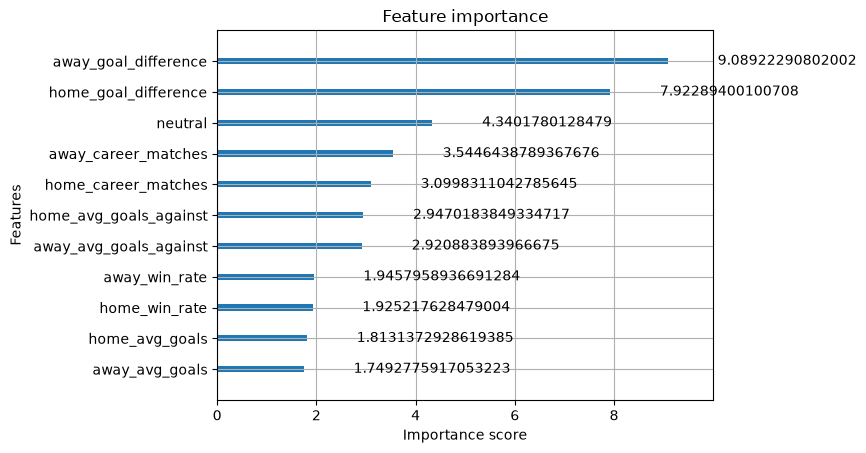

In [60]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(
    model,
    importance_type="gain"
)

plt.show()

## Evaluate both Models